<h1 style="font-weight:600;">Zomato Data Cleaning & Analysis</h1>

<p style="font-size:16px;">
Shrinithi | MSc Data Science | CIT
</p>

<hr>

<h2>Objective</h2>

<p>
This project focuses on cleaning and analyzing a real-world Zomato restaurant dataset.
The dataset contains several inconsistencies, including missing values, textual noise,
and mixed data formats that require preprocessing before analysis.
</p>

<h3>Key Goals</h3>

<ul>
  <li>Perform structured data cleaning</li>
  <li>Handle missing and inconsistent values</li>
  <li>Extract meaningful features from raw data</li>
  <li>Analyze patterns in restaurant ratings and pricing</li>
</ul>

<hr>

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("zomato.csv")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [24]:
df.sample(5)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
2409,https://www.zomato.com/bangalore/tarbouche-btm...,"Shop 4, 7th Main Road, 2nd Tage, BTM Layout, B...",Tarbouche,Yes,No,NEW,0,+91 9787747815,BTM,Quick Bites,NaN,"Turkish, Rolls",300,"[('Rated 5.0', 'RATED\n I just loved the humm...",[],Dine-out,Bannerghatta Road
36056,https://www.zomato.com/bangalore/asgardian-mor...,"45, 13th Cross, Madiwala, 1st Stage, BTM, Bang...",Asgardian Moreover Chai,No,No,NEW,0,+91 7829933307,BTM,Quick Bites,NaN,"Fast Food, Rolls, Juices",300,"[('Rated 5.0', 'RATED\n It was a wonderful ex...",[],Delivery,Koramangala 7th Block
21835,https://www.zomato.com/bangalore/hearts-unlock...,"18, 3rd Floor, 2nd Cross, NS Palya, Industrial...",Hearts Unlock Cafe,No,No,3.2/5,11,+91 9008143437\r\n+91 7259710298,BTM,Cafe,NaN,"Cafe, Healthy Food",500,"[('Rated 2.5', 'RATED\n Nice place for hookah...",[],Cafes,JP Nagar
28639,https://www.zomato.com/bangalore/shree-nandini...,"Shop 182, KHP Colony, 17D Main, Koramangala 5t...",Shree Nandini Andhra Mess,No,No,3.3 /5,5,+91 8050929847,Koramangala 5th Block,Mess,NaN,Andhra,150,[],[],Dine-out,Koramangala 4th Block
43761,https://www.zomato.com/bangalore/aroma-of-asia...,"37, Ground Floor, Adams Corner, Coles Road, Fr...",Aroma Of Asia,No,No,3.9 /5,49,+91 8747099948\n080 69999094,Frazer Town,Quick Bites,"Veg Momos, Honey Chilli Potatoes","Chinese, Momos",400,"[('Rated 5.0', 'RATED\n Pocket friendly place...",[],Dine-out,MG Road


In [25]:
df.shape

(51717, 17)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [27]:
df.describe()

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [28]:
df.describe(include="all")

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
count,51717,51717,51717,51717,51717,43942,51717.000000,50509,51696,51490,23639,51672,51371,51717,51717,51717,51717
unique,51717,11495,8792,2,2,64,NaN,14926,93,93,5271,2723,70,22513,9098,7,30
top,https://www.zomato.com/bangalore/jalsa-banasha...,Delivery Only,Cafe Coffee Day,Yes,No,NEW,NaN,080 43334321,BTM,Quick Bites,Biryani,North Indian,300,[],[],Delivery,BTM
freq,1,128,96,30444,45268,2208,NaN,216,5124,19132,182,2913,7576,7595,39617,25942,3279
mean,NaN,NaN,NaN,NaN,NaN,NaN,283.697527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,803.838853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,41.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,198.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
df.duplicated().sum()

np.int64(0)

<h2>Initial Observations</h2>

<p>
A preliminary review of the dataset reveals several structural and formatting issues that need to be addressed before analysis:
</p>

<ul>
  <li>Presence of mixed data types across multiple columns</li>
  <li>Missing and incomplete values in key fields</li>
  <li>Text-formatted numerical data (e.g., ratings and cost) requiring preprocessing</li>
</ul>

In [30]:
df = df.drop_duplicates()

<ul>
  <li>Duplicate records were removed to ensure data consistency.</li>
</ul>

In [31]:
df.columns = df.columns.str.strip()

<ul>
  <li>Removed extra spaces from column names and values to maintain consistency.</li>
</ul>

In [32]:
df = df.drop(['url', 'phone'], axis=1)

<ul>
  <li>Removed irrelevant columns to focus on key features for analysis.</li>
</ul>

In [33]:
df.isnull().sum()

address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [34]:
df = df.dropna(subset=['rate'])

<ul>
  <li>Removed rows with missing rating values, as ratings are a key variable for analysis.</li>
</ul>

In [35]:
df['rate'] = df['rate'].replace(['NEW', '-'], np.nan)
df['rate'] = df['rate'].str.split('/').str[0]
df['rate'] = df['rate'].astype(float)

<ul>
  <li>Converted ratings from mixed text formats (e.g., "4.1/5", "NEW") into numerical values.</li>
</ul>

In [36]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float)

<ul>
  <li>Removed commas from cost values and converted them into numeric format.</li>
</ul>

In [37]:
df['location'] = df['location'].str.lower().str.strip()
df['rest_type'] = df['rest_type'].str.lower().str.strip()

<ul>
  <li>Standardized location and restaurant type into a structured format.</li>
</ul>

In [38]:
df['cuisines'] = df['cuisines'].astype(str)
df['cuisines'] = df['cuisines'].str.lower().str.split(',')

In [39]:
df['cuisine_count'] = df['cuisines'].apply(lambda x: len(x) if isinstance(x, list) else 0)

<ul>
  <li>Structured cuisine data and extracted the number of cuisines per restaurant.</li>
</ul>

In [40]:
df = df[(df['rate'] >= 0) & (df['rate'] <= 5)]

<ul>
  <li>Validated rating values to ensure they fall within the range of 0 to 5.</li>
</ul>

In [41]:
df['cost_per_person'] = df['approx_cost(for two people)'] / 2

<ul>
  <li>Derived cost per person to better represent individual pricing.</li>
</ul>

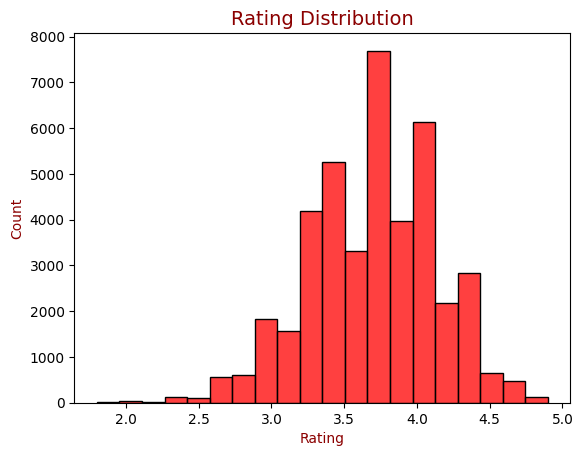

In [43]:
sns.histplot(df['rate'], bins=20, color='red')
plt.title("Rating Distribution", color='darkred', fontsize=14)
plt.xlabel("Rating", color='darkred')
plt.ylabel("Count", color='darkred')

plt.show()

<ul>
  <li>Most restaurants have ratings between 3.5 and 4.2, indicating average performance.</li>
</ul>

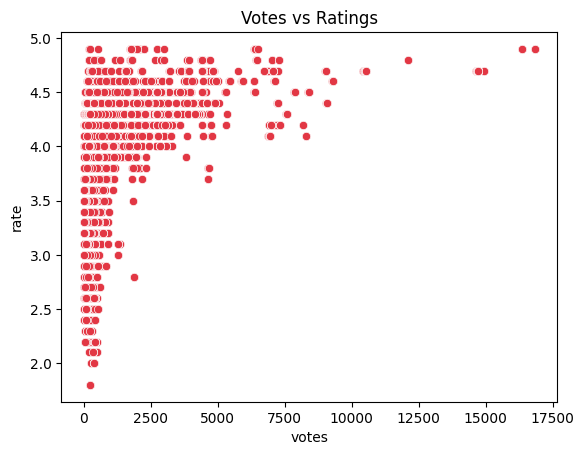

In [44]:
sns.scatterplot(x='votes', y='rate', data=df, color='#E23744')
plt.title("Votes vs Ratings")
plt.show()

<ul>
  <li>No strong relationship between votes and ratings, though higher votes indicate more reliable ratings.</li>
</ul>

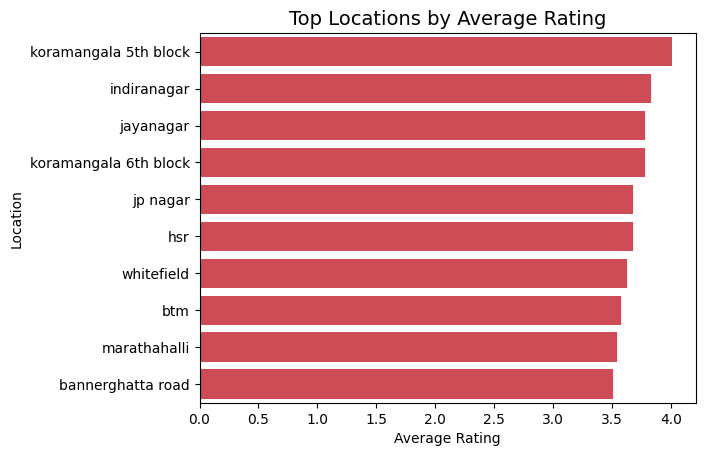

In [45]:
top_locations = df['location'].value_counts().head(10).index

avg_rating = df[df['location'].isin(top_locations)] \
    .groupby('location')['rate'].mean() \
    .sort_values(ascending=False)

sns.barplot(x=avg_rating.values, y=avg_rating.index, color='#E23744')

plt.title("Top Locations by Average Rating", fontsize=14)
plt.xlabel("Average Rating")
plt.ylabel("Location")

plt.show()

<ul>
  <li>Top locations have similar ratings (3.5–4.0), indicating consistent restaurant quality.</li>
</ul>

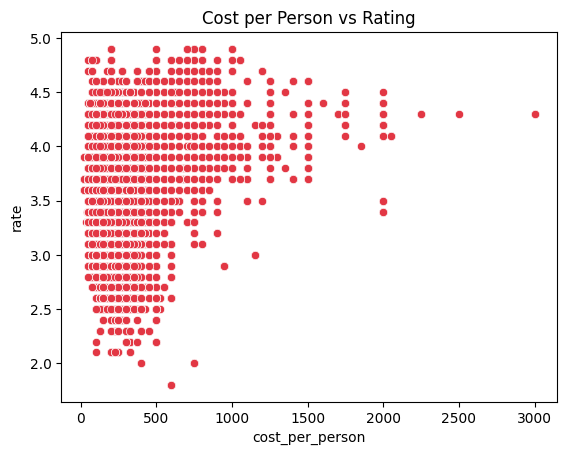

In [46]:
sns.scatterplot(x='cost_per_person', y='rate', data=df, color='#E23744')
plt.title("Cost per Person vs Rating")
plt.show()

<ul>
  <li>Higher cost does not necessarily lead to better ratings, indicating price is not a strong factor.</li>
</ul>

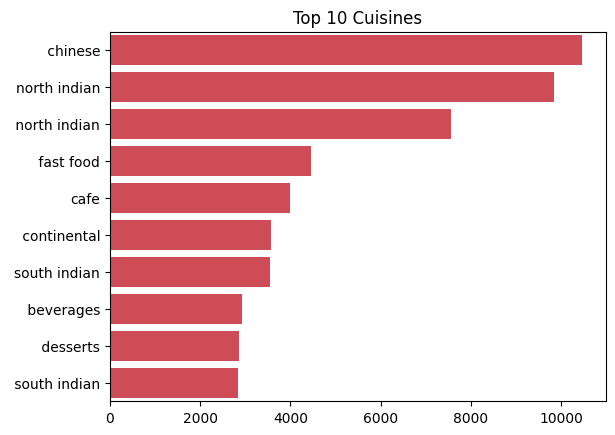

In [47]:
from collections import Counter

all_cuisines = df['cuisines'].dropna().sum()
top_cuisines = Counter(all_cuisines).most_common(10)

cuisine_names = [i[0] for i in top_cuisines]
cuisine_counts = [i[1] for i in top_cuisines]

sns.barplot(x=cuisine_counts, y=cuisine_names, color='#E23744')
plt.title("Top 10 Cuisines")
plt.show()

<ul>
  <li>North Indian and Chinese cuisines dominate the dataset, indicating customer preference trends.</li>
</ul>

<h2>Key Insights</h2>

<p>
The analysis highlights several patterns in customer preferences and restaurant performance:
</p>

<ul>
  <li>Higher vote counts are associated with more stable and reliable ratings.</li>
  <li>Price has limited influence on ratings, indicating that higher cost does not guarantee better reviews.</li>
  <li>Restaurants offering a wider variety of cuisines tend to receive slightly higher ratings.</li>
</ul>

<h2>Limitations</h2>

<p>
Despite careful analysis, the study has certain limitations that should be considered:
</p>

<ul>
  <li>Ratings are subjective and influenced by individual preferences.</li>
  <li>Data cleaning and missing value handling may impact analytical accuracy.</li>
  <li>The dataset is limited to specific locations and may not fully represent broader regions.</li>
</ul>

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

df_model = df[['rate', 'votes', 'cost_per_person', 'cuisine_count']].dropna()

X = df_model.drop('rate', axis=1)
y = df_model['rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

comparison = pd.DataFrame({
    "Model": ["Random Forest", "Linear Regression"],
    "MAE": [rf_mae, lr_mae],
    "RMSE": [rf_rmse, lr_rmse],
    "R2 Score": [rf_r2, lr_r2]
})

print("\nModel Comparison:")
print(comparison)

best_model = comparison.loc[comparison['MAE'].idxmin()]
print("\nBest Model:", best_model['Model'])


Model Comparison:
               Model       MAE      RMSE  R2 Score
0      Random Forest  0.124803  0.220712  0.745037
1  Linear Regression  0.291799  0.377500  0.254135

Best Model: Random Forest


<h2>Model Insights</h2>

<ul>
  <li>Random Forest demonstrated superior performance compared to Linear Regression, with lower error metrics and a higher R² score.</li>
  <li>This indicates the presence of non-linear relationships between features and ratings.</li>
  <li>Votes and cuisine-related features contribute to predictions, although their influence remains moderate.</li>
  <li>Overall, the model achieves good predictive performance with low error.</li>
</ul>